# The Anatomy of a Hit - Complete Analysis

**Project Goal**: Analyze how musical identity drifts over decades and what data reveals about cultural homogenization in hit songs.

**Core Question**: Are all hit songs starting to sound and say the same thing — and if so, when did it start?

## Phase 0: Data Collection Setup

In [2]:
# Install required packages
!pip3 install -r requirements.txt
!python3 -m spacy download en_core_web_sm

  Using cached billboard.py-7.1.0-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached joypy-0.2.6-py2.py3-none-any.whl.metadata (812 bytes)
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached ipykernel-7.2.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.

In [4]:
!pip3 install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Step 1: Billboard Data Collection

Run the Billboard data collection to generate our master song list.

In [2]:
# Execute Phase 0 - Billboard data collection
%run Phase_0_Billboard_Data.ipynb

Libraries imported successfully
Normalization functions defined
Billboard collection function defined
Starting Billboard data collection...



Collected 5053 songs total
Years covered: 1970 - 2023
Before deduplication: 5053 songs
After deduplication: 3362 unique songs

Sample of the data:
                              title             artist  year  chart_position  \
0        bridge over troubled water  simon & garfunkel  1970               1   
1                      close to you         carpenters  1970               2   
2    american womanno sugar tonight      the guess who  1970               3   
3  raindrops keep fallin on my head        b.j. thomas  1970               4   
4                               war        edwin starr  1970               5   

   weeks_on_chart decade  top10  
0               1  1970s      1  
1               1  1970s      1  
2               1  1970s      1  
3               1  1970s      1  
4               1  1970s      1  
Songs by decade:
decade
1970s    796
1980s    866
1990s    189
2000s    269
2010s    888
2020s    354
Name: count, dtype: int64

Top 10 hits by decade:
decade
1970s   

## Step 2: Audio Features Collection

In [6]:
!pip3 install yt-dlp librosa


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [ ]:
exec(open('audio_features.py').read())

Loaded 4801 songs from songs.csv
yt-dlp version: 2026.03.13
Loaded 4779 cached results
Processing 22 remaining songs...


yt-dlp error for 'viva la vida': ERROR: [youtube] MY4eEOB1wSI: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dl


yt-dlp error for 'sober': ERROR: [youtube] 4Kk4xtkBalY: This video is not available



yt-dlp error for 'tonight': ERROR: [youtube] -yFj3FvoOWY: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dl


yt-dlp error for 'let it go': ERROR: [youtube] FnpJBkAMk44: This video is not available



...

yt-dlp error for 'hooked on a feeling': ERROR: [youtube] u5b5l5o6JIA: This video is not available



yt-dlp error for 'riddle': ERROR: [youtube] _gRIz5563g8: This video is not available



yt-dlp error for 'get it poppin': ERROR: [youtube] 6vVHG6Xpoxs: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dl


Checkpoint: 4785 saved, 20 processed


Before cleaning: 4787 songs
After cleaning: 4782 songs
Saved audio_clean.csv

Final results:
Successfully processed: 4782 songs
Failed: 0 songs
Success rate: 99.6%


## Step 3: Genius Lyrics Collection

**⚠️ Important**: You need to set up Genius API credentials first:
1. Go to https://genius.com/api-clients
2. Create a new API client
3. Get your Access Token
4. Set environment variables or modify the script

In [44]:
# Set your Genius credentials (replace with your actual credentials)
os.environ['GENIUS_ACCESS_TOKEN'] = '06cjAkkFfNOn0dBvoWQ3zzM04Jzv8zhI9du_MHXPvuwTqBS4ACwzM1pnL4URtCR6'

# Run Genius lyrics collection
exec(open('genius_lyrics_scraper.py').read())

Loaded 4801 songs from songs.csv
Loaded 3288 cached lyrics
Processing 1513 remaining songs...


Validation failed for rocket man by elton john: Lyrics too short
Validation failed for rocket man by elton john: Lyrics too short
Validation failed for rocket man by elton john: Lyrics too short


Checkpoint: 3288 lyrics saved


Checkpoint: 3288 lyrics saved


Checkpoint: 3288 lyrics saved


...

Checkpoint: 4651 lyrics saved


Checkpoint: 4661 lyrics saved


Checkpoint: 4671 lyrics saved


Checkpoint: 4681 lyrics saved


Saved 3 new lyrics
\nFinal results:
Successfully processed: 4684 songs
Failed: 0 songs
Success rate: 97.6%
\nLyrics statistics:
Average word count: 434.9
Average lexical diversity: 0.362


## Step 4: Audio Feature Analysis

Loaded 4782 songs with audio features
Decades covered: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Starting Audio Feature Analysis...

1. Analyzing feature trends over time...


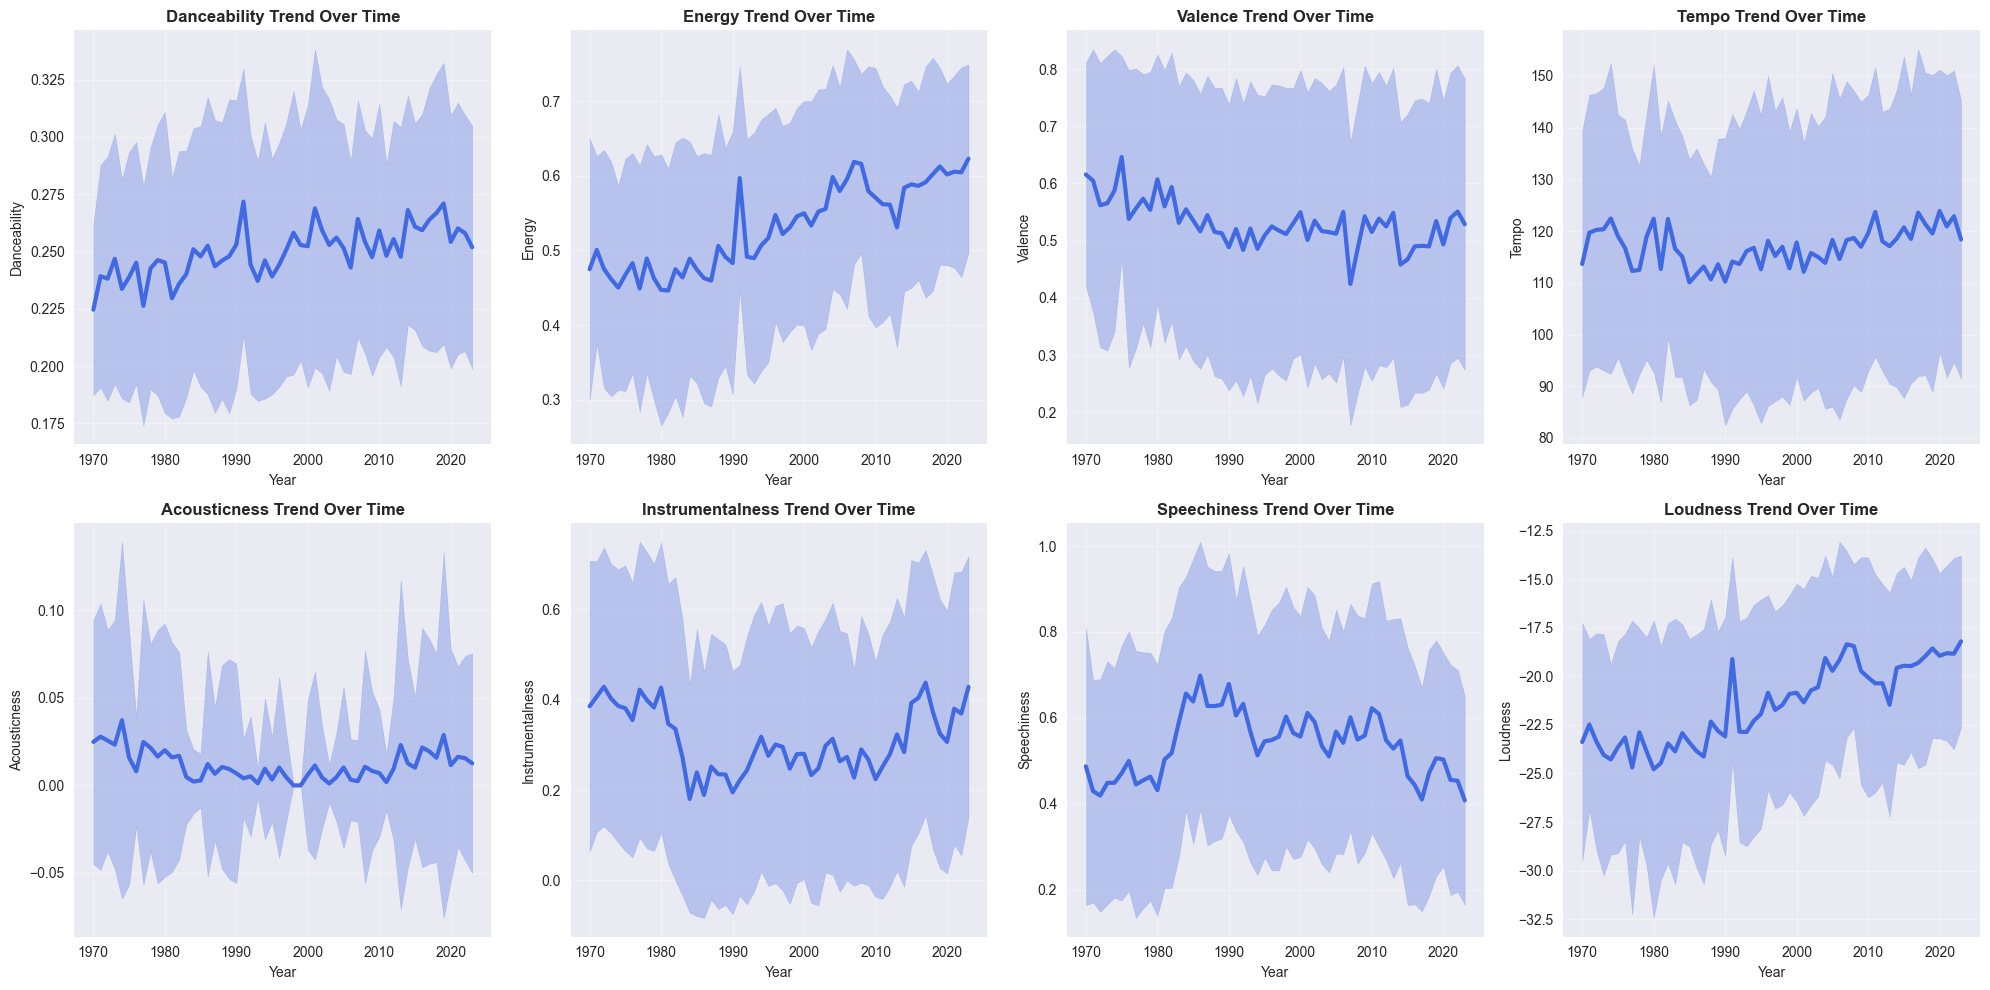


Analysis complete! Check audio_feature_trends.png


In [2]:
# Run audio analysis
exec(open('audio_analysis.py').read())

## Step 5: NLP Lyrics Analysis

Loaded 4554 songs with lyrics
Decades covered: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Starting NLP Lyrics Analysis...

1. Computing and saving sentiment...


Analyzing sentiment: 100%|██████████| 4554/4554 [00:08<00:00, 538.91it/s]


Saved sentiment columns to lyrics_clean.csv

2. Computing and saving LZ77 compressibility...

LZ77 Compressibility by Decade (higher = more repetitive):
         mean    std  count
decade                     
1970s   0.773  0.294    763
1980s   0.795  0.242    853
1990s   0.768  0.264    908
2000s   0.787  0.226    852
2010s   0.848  0.255    847
2020s   0.750  0.260    331

3. Running LDA topic modeling...


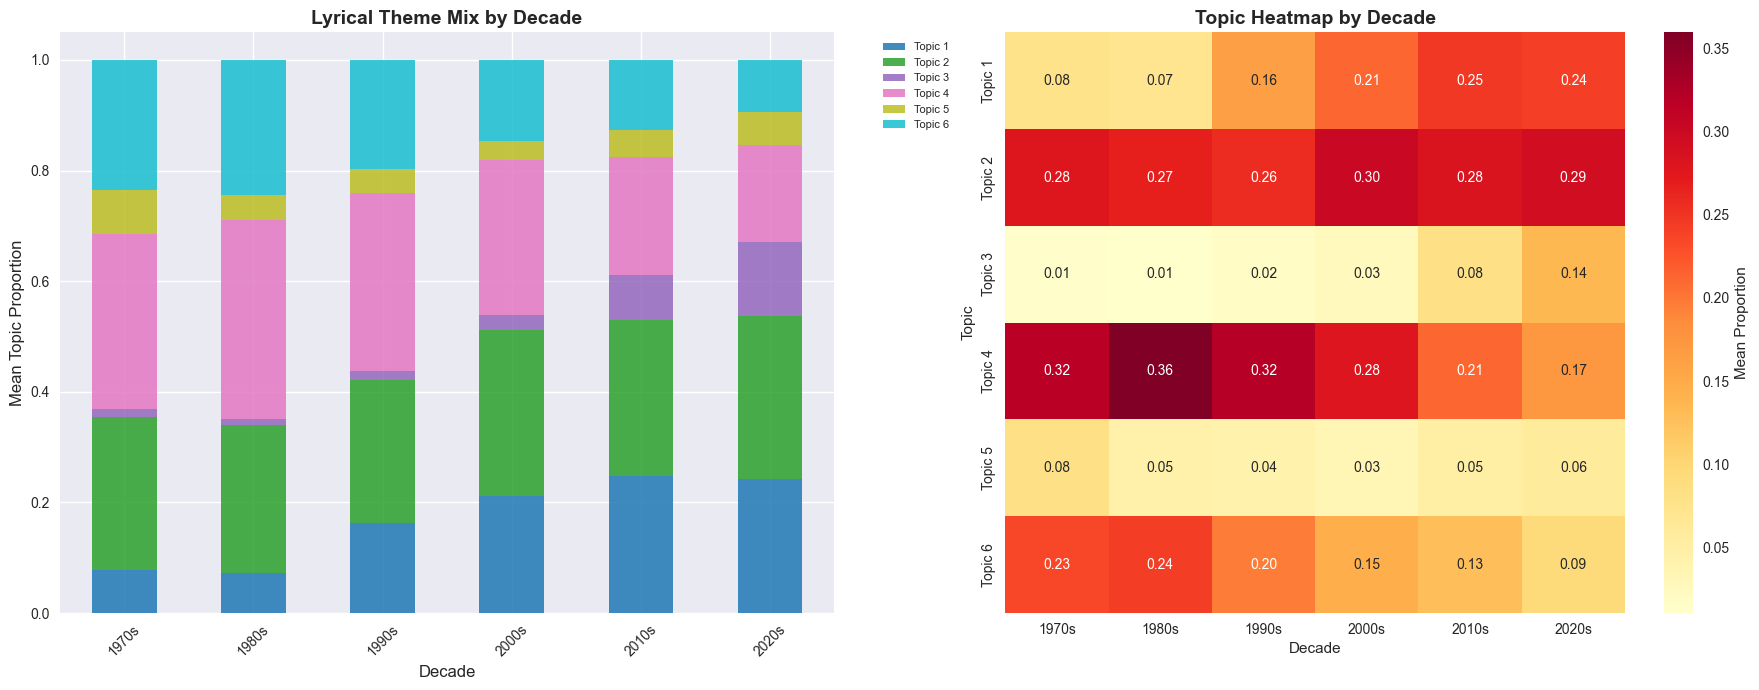


Top words per topic:
  Topic 1: shit, nigga, em, bitch
  Topic 2: girl, time, night, think
  Topic 3: shake, eu, se, di
  Topic 4: away, love, life, day
  Topic 5: doo, everybody, low, woah
  Topic 6: love, tonight, good, time

4. Running significance tests...

Lexical Diversity — Statistical Significance
Kruskal-Wallis H=99.89, p=5.5646e-20 (SIGNIFICANT)

Pairwise Mann-Whitney U (Bonferroni corrected, n=15):
Pair                         p (raw)    p (Bonf.)   Sig?
-------------------------------------------------------
1970s vs 1980s          0.0002       0.0025     **
1970s vs 1990s          0.0001       0.0008    ***
1970s vs 2000s          0.0000       0.0000    ***
1970s vs 2010s          0.0000       0.0000    ***
1970s vs 2020s          0.3384       1.0000       
1980s vs 1990s          0.7331       1.0000       
1980s vs 2000s          0.0063       0.0951       
1980s vs 2010s          0.0000       0.0000    ***
1980s vs 2020s          0.0208       0.3113       
1990s vs 2000s

In [3]:
# Run NLP analysis
exec(open('nlp_analysis.py').read())

## Step 6: Merge Datasets

In [4]:
# Merge audio and lyrics datasets
exec(open('merge_datasets.py').read())

Audio dataset: 4782 songs
Lyrics dataset: 4554 songs
Dropped duplicate columns from lyrics before merge: ['decade', 'chart_position']

Merging audio and lyrics datasets...
Merged dataset: 4537 songs
Merge success rate: 94.9%
Final clean dataset: 4537 songs
Years covered: 1970 - 2023
Decades: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Saved merged dataset to merged.csv

Merge complete! Ready for final_analysis.py.


## Step 7: Final Combined Analysis

Loaded merged dataset: 4537 songs
Years: 1970 - 2023
Decades: 1970s, 1980s, 1990s, 2000s, 2010s, 2020s
Starting Final Combined Analysis...

1. Training predictive models...

Training Random Forest...
  Accuracy: 0.343
  Macro F1: 0.296
  CV Score: 0.335 ± 0.022

  Confusion matrix (rows=true, cols=predicted):
           1970s   1980s   1990s   2000s   2010s   2020s
  1970s      0.52    0.24    0.08    0.11    0.06    0.00
  1980s      0.26    0.45    0.11    0.05    0.12    0.00
  1990s      0.19    0.23    0.21    0.19    0.19    0.00
  2000s      0.12    0.12    0.22    0.25    0.28    0.01
  2010s      0.11    0.13    0.11    0.20    0.43    0.02
  2020s      0.08    0.15    0.12    0.15    0.48    0.02

  Per-decade recall:
    1970s: 0.52 ██████████
    1980s: 0.45 █████████
    1990s: 0.21 ████
    2000s: 0.25 █████
    2010s: 0.43 ████████
    2020s: 0.02 

Training KNN...
  Accuracy: 0.290
  Macro F1: 0.261
  CV Score: 0.273 ± 0.007

  Confusion matrix (rows=true, cols=predicte

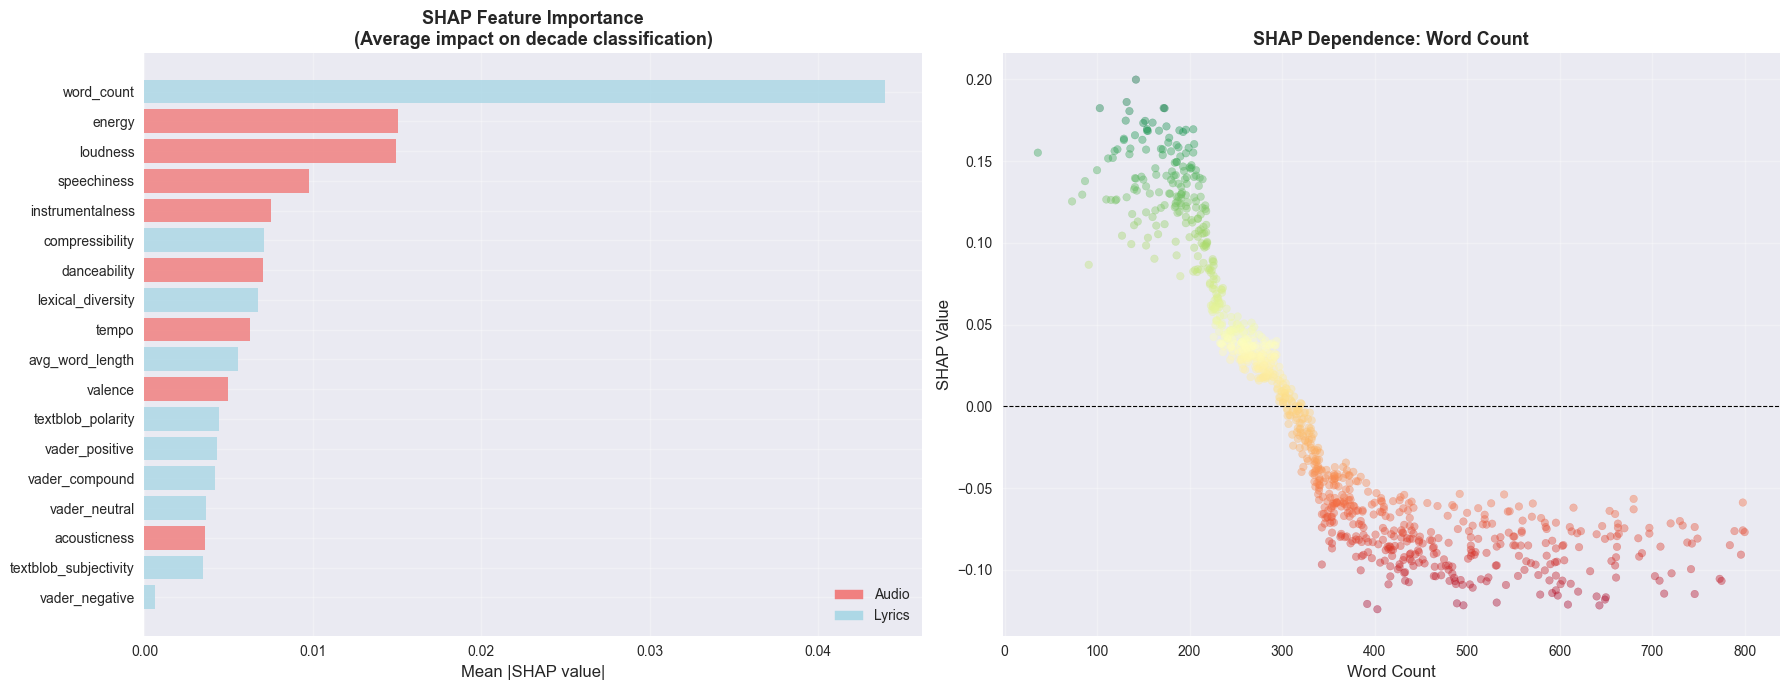


SHAP split: Audio 45.1% vs Lyrics 54.9%

3. Temporal patterns (lexical diversity + sentiment)...


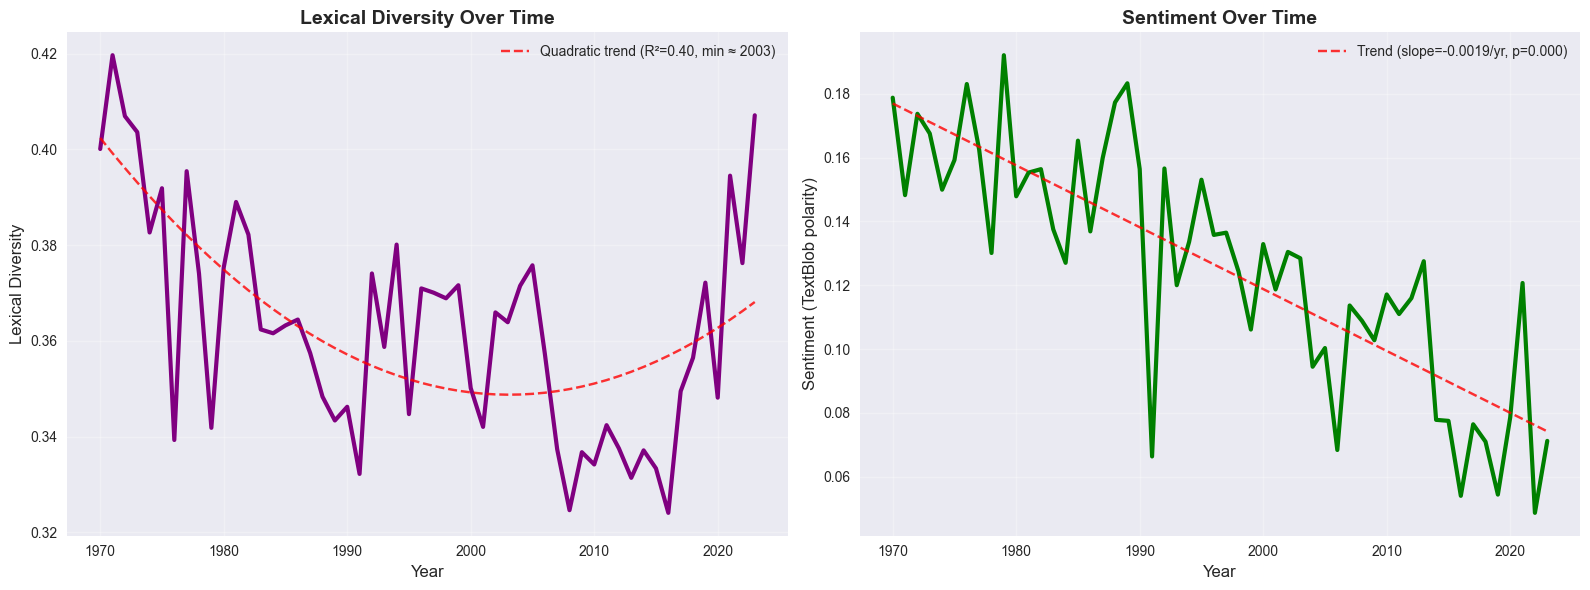


4. Decade sonic similarity heatmap...


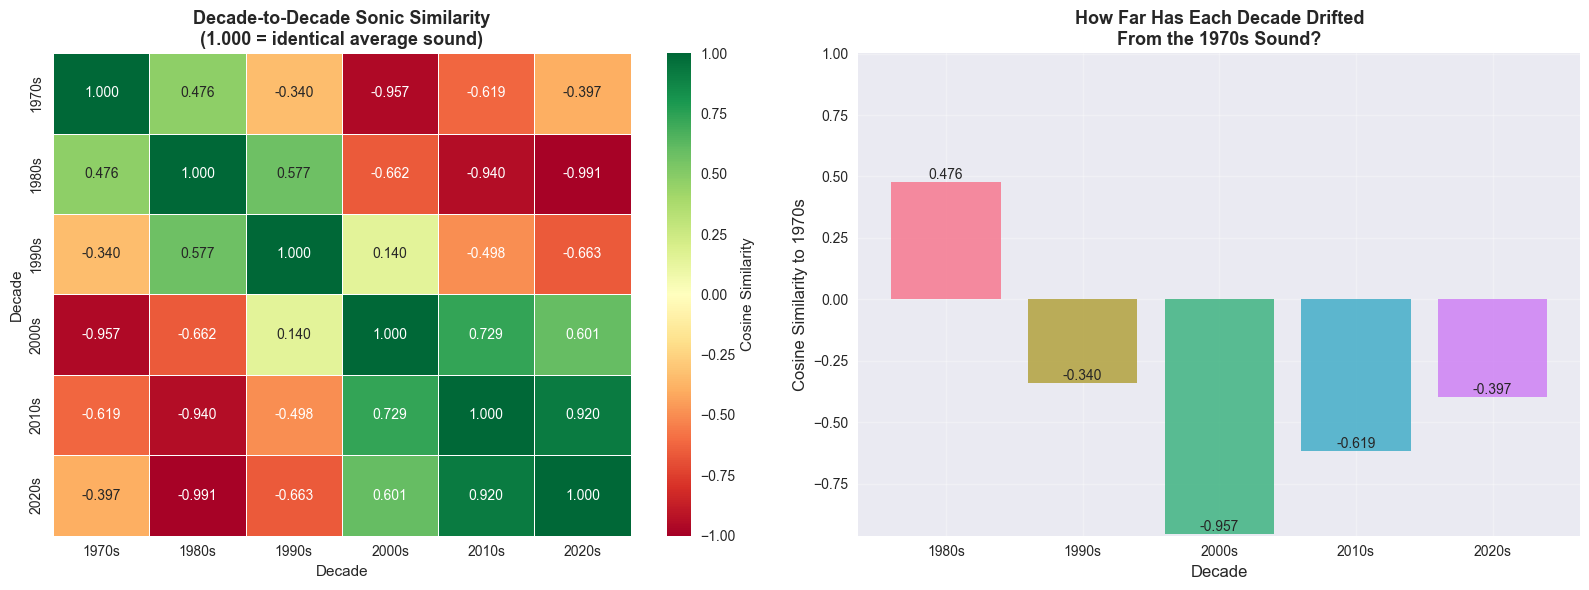


Decade Cosine Similarity Matrix:
        1970s   1980s   1990s   2000s   2010s   2020s
1970s  1.0000  0.4758 -0.3403 -0.9571 -0.6188 -0.3968
1980s  0.4758  1.0000  0.5771 -0.6619 -0.9397 -0.9907
1990s -0.3403  0.5771  1.0000  0.1405 -0.4983 -0.6631
2000s -0.9571 -0.6619  0.1405  1.0000  0.7293  0.6009
2010s -0.6188 -0.9397 -0.4983  0.7293  1.0000  0.9199
2020s -0.3968 -0.9907 -0.6631  0.6009  0.9199  1.0000

5. Hierarchical clustering dendrogram...


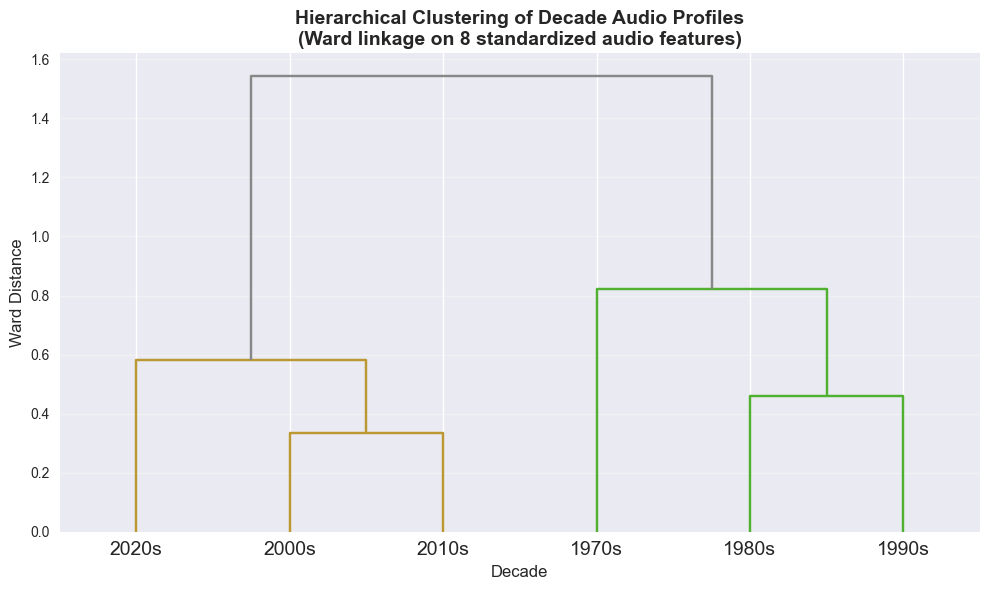


Decade Dendrogram linkage matrix (Ward):
   idx1  idx2  distance  count
0   3.0   4.0    0.3356    2.0
1   1.0   2.0    0.4605    2.0
2   5.0   6.0    0.5819    3.0
3   0.0   7.0    0.8215    3.0
4   8.0   9.0    1.5436    6.0

6. K-Means cluster heatmap (combined features)...


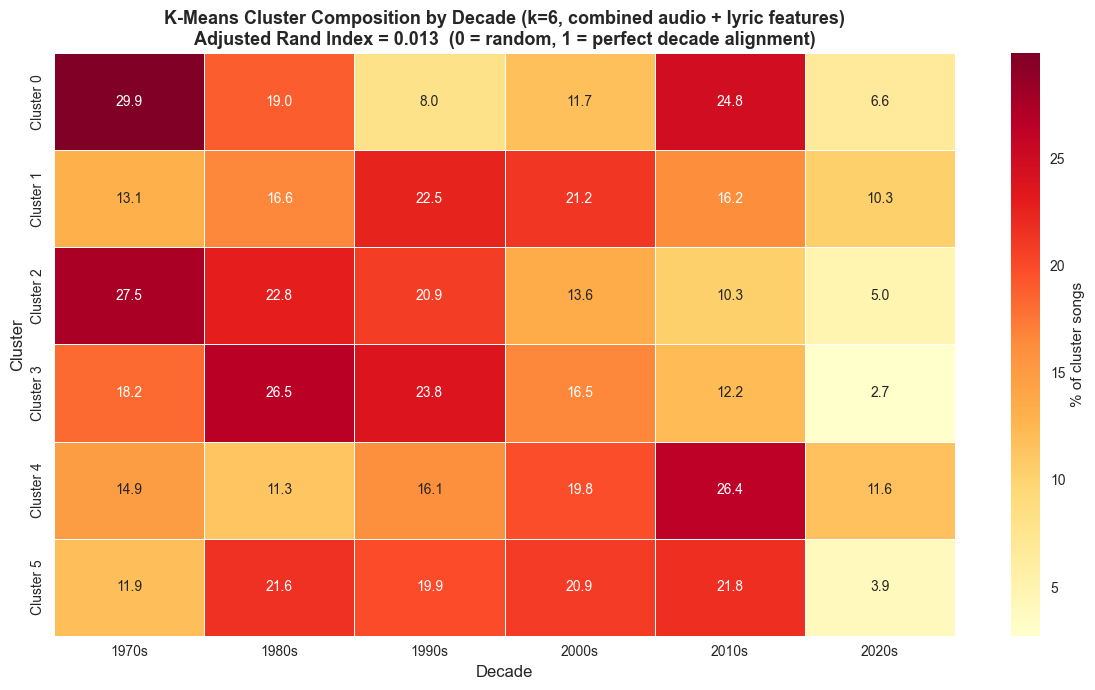


Adjusted Rand Index (clusters vs decades): 0.0131

Cluster composition (% per decade):
decade     1970s  1980s  1990s  2000s  2010s  2020s
Cluster 0   29.9   19.0    8.0   11.7   24.8    6.6
Cluster 1   13.1   16.6   22.5   21.2   16.2   10.3
Cluster 2   27.5   22.8   20.9   13.6   10.3    5.0
Cluster 3   18.2   26.5   23.8   16.5   12.2    2.7
Cluster 4   14.9   11.3   16.1   19.8   26.4   11.6
Cluster 5   11.9   21.6   19.9   20.9   21.8    3.9

Analysis complete! Check the generated PNG files.

Best decade classifier: Random Forest with 34.3% accuracy


In [5]:
# Run final analysis and ML modeling
exec(open('final_analysis.py').read())